<a href="https://colab.research.google.com/github/farrelandika/PCVK_Genap_2021/blob/main/Pertemuan2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
from google.colab import drive
drive.mount('/content/drive')
from google.colab import files
uploaded = files.upload()  # akan muncul dialog pilih file

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


TypeError: 'NoneType' object is not subscriptable

In [ ]:
# Replace 'path/to/your/data.csv' with the actual path to your file in Google Drive
file_path = '/content/drive/MyDrive/path/to/your/data.csv'

# Example: if your data is a CSV file, you can load it with pandas
import pandas as pd
df = pd.read_csv(file_path)
display(df.head())

In [ ]:
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow  # untuk menampilkan image di Colab
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt

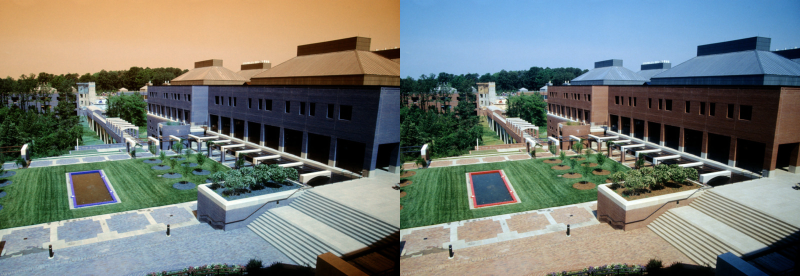

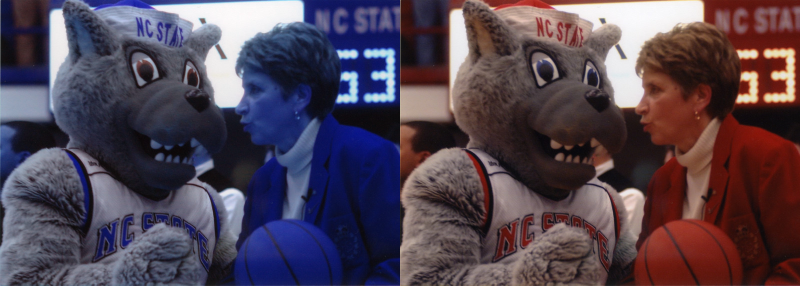

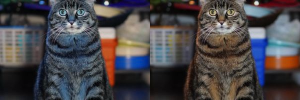

In [ ]:
# Membuat list untuk menyimpan url dari beberapa image
urls = ["https://iiif.lib.ncsu.edu/iiif/0052574/full/800,/0/default.jpg",
        "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg",
        "https://placecats.com/300/200"]

# baca dan tampilkan image
# loop pada tiap url image, beberapa image dapat disimpan pada list
for url in urls:
    image = io.imread(url)                              # read image
    image = cv.resize(image, (0,0), fx=0.5, fy=0.5)      # resize image to half size
    image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)       # convert color to RGB
    final_frame = cv.hconcat((image, image_2))           # concatenate image
    cv2_imshow(final_frame)                              # show image
    print('\n')

Resolusi image : tinggi x lebar =  100  x  150


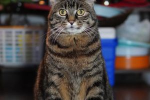

In [ ]:
tinggi = image_2.shape[0]
lebar = image_2.shape[1]
print("Resolusi image : tinggi x lebar = " , tinggi, " x " , lebar)
cv2_imshow(image_2)

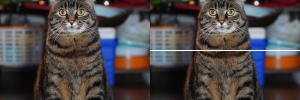

In [ ]:
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# membuat garis horizontal di tengah image
for y in range(lebar):
    image_3[int(tinggi/2), y] = [255, 255, 255]

final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)

In [ ]:
#PERTANYAAN PRAKTIKUM D2
1. Jelaskan, mengapa pada modul praktikum ini eksekusi kode Python dilakukan
menggunakan Google Colab?
2. Jelaskan mengenai kegunaan setiap library pada praktikum langkah ke
delapan? Apakah semua library tersebut harus digunakan dalam praktikum
sesi ini?
3. Pada uji coba langkah ke-9 terdapat potongan kode program sebagai berikut :
Apa kegunaan kode program tersebut?dan apa pengaruhnya jika tidak
dilakukan?
4. Perhatikan potongan kode progam berikut :
Apakah kegunaan kode [255,255,255] ? Jelaskan!
5. Jelaskan keterkaitan antara pixel dan juga resolusi gambar yang tinggi ataupun
rendah

#JAWABAN
1. Karena google colab memiliki banyak keunggulan, yaitu beberapa mencakup berbasis
cloud dan gratis, dapat terintegrasi dengan github dan google drive, dan dapat diakses
dengan mudah.

2. Kegunaan setiap library pada
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt
a. yaitu untuk Numpy sendiri, untuk Manipulasi array numerik
 (operasi vektor/matriks), dasar representasi citra sebagai array.
b. pandas yaitu Manipulasi dan analisis data tabular
 (tidak selalu untuk citra langsung)
c. cv2 (OpenCV)	Pengolahan citra utama: baca, tampilkan, transformasi,
deteksi objek
d. cv2_imshow	Fungsi khusus untuk menampilkan image di lingkungan Google
Colab (karena cv2.imshow() biasa tidak berjalan di Colab)
e. skimage (io)	Membaca citra, termasuk dari URL
f. skimage (transform)	Fungsi transformasi citra
tingkat lanjut (resize, rotate, dll.)
g. PIL (Image)	Library alternatif untuk membuka dan memanipulasi citra
h. Matplotlib	Visualisasi/plotting citra beserta informasi sumbu (ukuran piksel)

3. kode cv.resize(image, (0,0), fx=0.5, fy=0.5) digunakan untuk mengubah ukuran
 (resize) citra menjadi setengah dari ukuran aslinya, dengan parameter:
(0,0) → ukuran tujuan tidak ditentukan secara eksplisit dalam piksel
fx=0.5 → skala lebar menjadi 50% dari ukuran asli
fy=0.5 → skala tinggi menjadi 50% dari ukuran asli
Jika tidak dilakukan: citra akan tetap tampil dalam ukuran aslinya
(bisa jadi cukup besar, misalnya 800px), sehingga saat digabungkan (hconcat)
dengan citra lain untuk ditampilkan berdampingan,
ukurannya menjadi lebih besar/berat dan bisa memenuhi
tampilan output tanpa efisiensi ruang.

4. Kegunaan kode [255, 255, 255] pada:
for y in range(lebar):
    image_3[int(tinggi/2), y] = [255, 255, 255]
yaitu agar nilai rgb menjadi warna
putih kertas

5. Untuk pixel sendiri yaitu adalah unit terkecil penyusun sebuah citra digital
yang mana seetiap pixel memiliki nilai intensitas berupa greyscale atau true color
(RGB) sedangkan untuk resolusi sendiri adalah jumlah pixel yang menyusun citra dalam
dimensi vertikal x horizontal contohnya yaitu 1920x1080

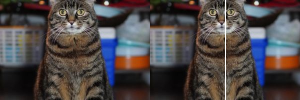

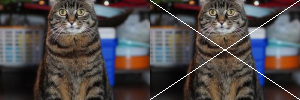

In [ ]:
#Tugas Praktikum D2
# 2. Membuat Garis Vertikal dan Garis Menyilang Diagonal
image_vertikal = image_2.copy()

# Garis Vertikal di tengah image
for x in range(tinggi):
    image_vertikal[x, int(lebar/2)] = [255, 255, 255]

# Garis Diagonal Menyilang
image_diagonal = image_2.copy()

cv.line(image_diagonal, pt1=(0, 0), pt2=(lebar-1, tinggi-1), color=(255, 255, 255), thickness=1)
cv.line(image_diagonal, pt1=(lebar-1, 0), pt2=(0, tinggi-1), color=(255, 255, 255), thickness=1)

# gabungkan image asli dengan hasil garis vertikal + diagonal
final_frame = cv.hconcat((image_2, image_vertikal))
final_frame2 = cv.hconcat((image_2, image_diagonal))

cv2_imshow(final_frame)
print('\n')
cv2_imshow(final_frame2)

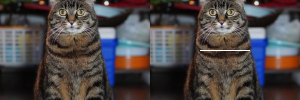

In [ ]:
# 3. Membuat Garis Horizontal Berwarna Putih dengan Panjang Tertentu
image_horizontal = image_2.copy()

# tentukan panjang garis yang diinginkan (misal 50 pixel, mulai dari tengah)
panjang_garis = 50
mulai_x = int((lebar - panjang_garis) / 2)   # posisi awal garis (biar di tengah)
y_tengah = int(tinggi / 2)

for x in range(mulai_x, mulai_x + panjang_garis):
    image_horizontal[y_tengah, x] = [255, 255, 255]

final_frame3 = cv.hconcat((image_2, image_horizontal))
cv2_imshow(final_frame3)

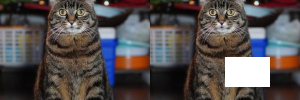

In [ ]:
# 4. Membuat Kotak Menggunakan Kumpulan Pixel Warna Putih
import random # Import modul random untuk posisi acak

gambar_kotak = image_2.copy()

# Tentukan ukuran kotak (misalnya, 30% dari tinggi dan lebar gambar)
tinggi_kotak = int(tinggi * 0.3)
lebar_kotak = int(lebar * 0.3)

# Tentukan posisi awal kotak secara acak, pastikan tidak keluar batas gambar
baris_awal = random.randint(0, tinggi - tinggi_kotak - 1)
kolom_awal = random.randint(0, lebar - lebar_kotak - 1)

baris_akhir = baris_awal + tinggi_kotak
kolom_akhir = kolom_awal + lebar_kotak

for baris in range(baris_awal, baris_akhir):
    for kolom in range(kolom_awal, kolom_akhir):
        gambar_kotak[baris, kolom] = [255, 255, 255] # Mengatur piksel menjadi putih

bingkai_akhir_4 = cv.hconcat((image_2, gambar_kotak))
cv2_imshow(bingkai_akhir_4)

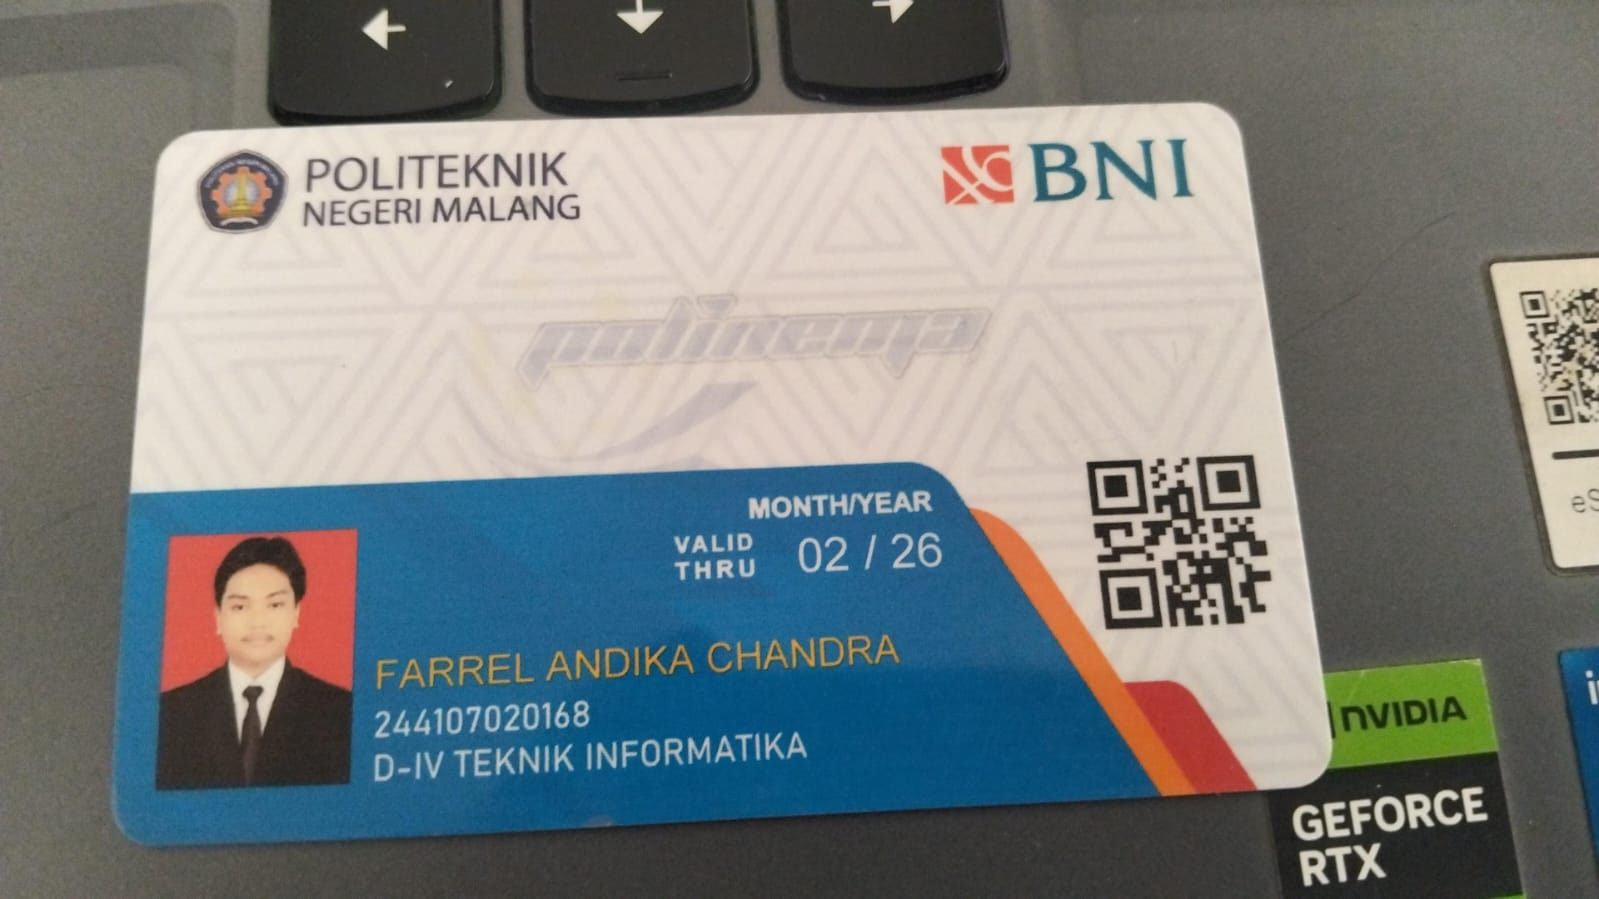

Resolusi gambar: 1599 x 899


In [30]:
# D3. Pengenalan Python: Pengolahan Citra Dasar dan memahami channel warna pada OpenCV dan konversinya
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread("/content/drive/MyDrive/PCVK/WhatsApp Image 2026-09-01 at 4.54.04 PM.jpeg")
cv2_imshow(img)

print("Resolusi gambar:", img.shape[1], "x", img.shape[0])

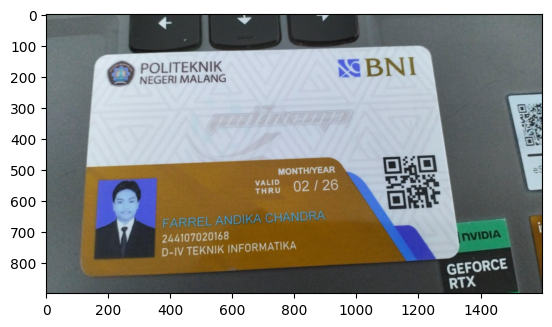

In [ ]:
# Menampilkan Gambar dengan matplotlib
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

img = cv2.imread("/content/drive/MyDrive/PCVK/WhatsApp Image 2026-09-01 at 4.54.04 PM.jpeg")
plt.imshow(img) #Format waena BGR

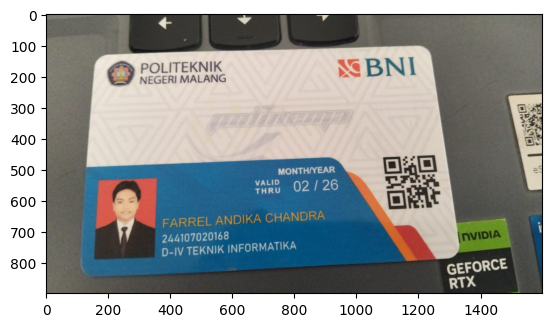

In [29]:
# Konversi BGR → RGB:
img = cv2.imread("/content/drive/MyDrive/PCVK/WhatsApp Image 2026-09-01 at 4.54.04 PM.jpeg")
img2 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Konversi BGR ke RGB
plt.imshow(img2)

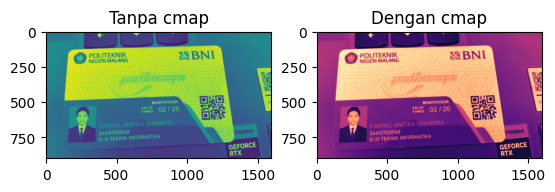

In [31]:
# Langkah 3_Menampilkan Citra Grayscale
img_gray = cv2.imread("/content/drive/MyDrive/PCVK/WhatsApp Image 2026-09-01 at 4.54.04 PM.jpeg", cv2.IMREAD_GRAYSCALE)

# Tanpa cmap
plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title("Tanpa cmap")

# Dengan cmap
plt.subplot(1,2,2)
plt.imshow(img_gray, cmap="gray")
plt.title("Dengan cmap")

plt.show()

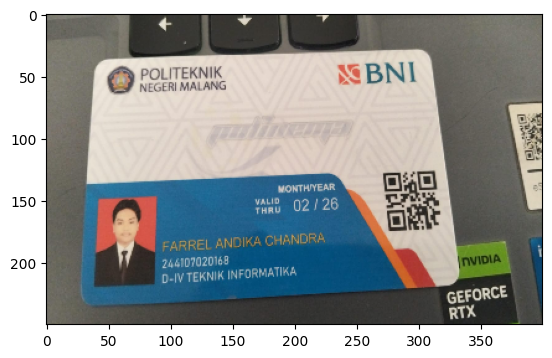

In [33]:
# Langkah 4 Reizing Citra
img = cv2.imread("/content/drive/MyDrive/PCVK/WhatsApp Image 2026-09-01 at 4.54.04 PM.jpeg")
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   # Konversi BGR ke RGB
imgRGBsmall = cv2.resize(imgRGB, (400, 250))
plt.imshow(imgRGBsmall)

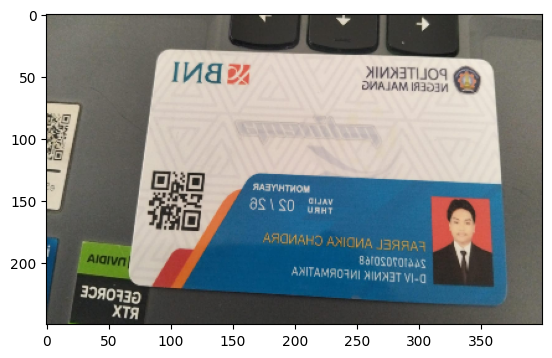

In [34]:
# Langkah 5 Melakukan Flipping
imgBalik = cv2.flip(imgRGBsmall, 1)
plt.imshow(imgBalik)

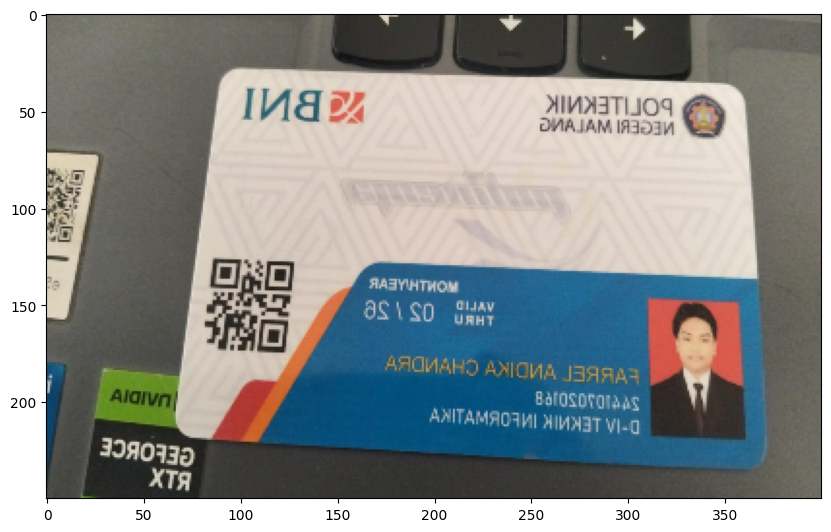

In [35]:
# Menampilkan dengan canvas yang lebih besar
imgBalik = cv2.flip(imgRGBsmall, 1)

# tampilkan ukuran canvas yang lebih besar
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
ax.imshow(imgBalik)

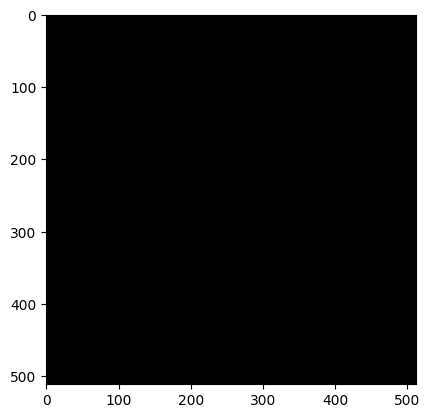

In [36]:
# Langkah 6 Membuat bentuk geometri 2D dengan OpenCV
# a. Membuat black image (tipe data int16):
black_img = np.zeros(shape=(512, 512, 3), dtype=np.int16)
plt.imshow(black_img)

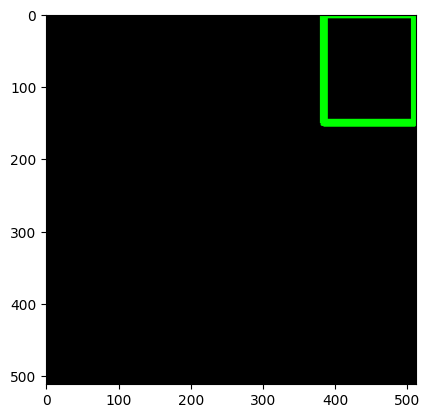

In [37]:
# b. Menambahkan Persegi panjang
# perhatikan koordinat titik pt1 dan pt2
cv.rectangle(black_img, pt1=(384, 0), pt2=(510, 150), color=(0, 255, 0), thickness=10)
plt.imshow(black_img)

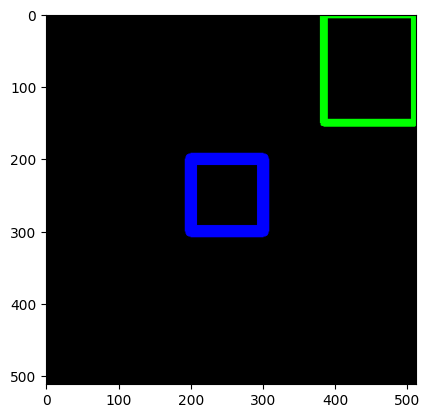

In [38]:
# c. Menambahkan persegi kedua
cv.rectangle(black_img, pt1=(200, 200), pt2=(300, 300), color=(0, 0, 255), thickness=15)
plt.imshow(black_img)

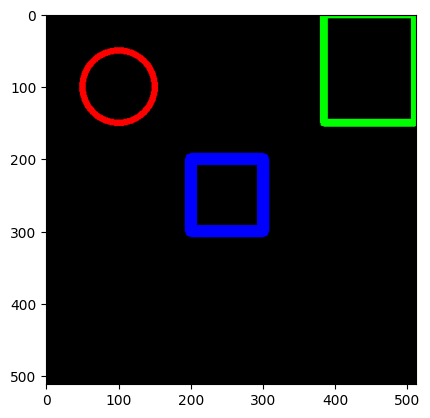

In [39]:
# d. Menambahkan Lingkaran
cv.circle(black_img, center=(100, 100), radius=50, color=(255, 0, 0), thickness=8)
plt.imshow(black_img)

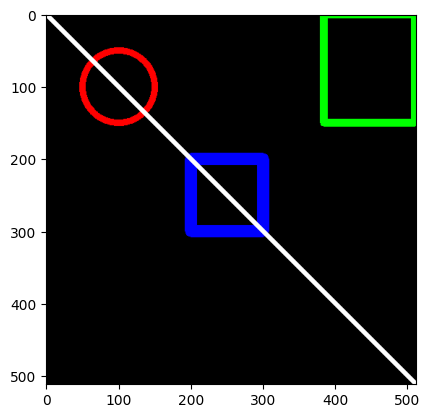

In [40]:
# e. Menambahkan garis diagonal
cv.line(black_img, pt1=(0, 0), pt2=(512, 512), color=(255, 255, 255), thickness=5)
plt.imshow(black_img)

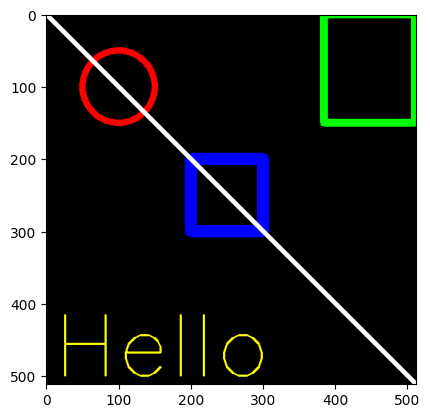

In [41]:
# f. Menambahkan text
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img, text='Hello', org=(10, 500), fontFace=font,
           fontScale=4, color=(255, 255, 0), thickness=2, lineType=cv.LINE_AA)
plt.imshow(black_img)

[[100 300]
 [200 200]
 [400 300]
 [200 400]]
[[[100 300]]

 [[200 200]]

 [[400 300]]

 [[200 400]]]


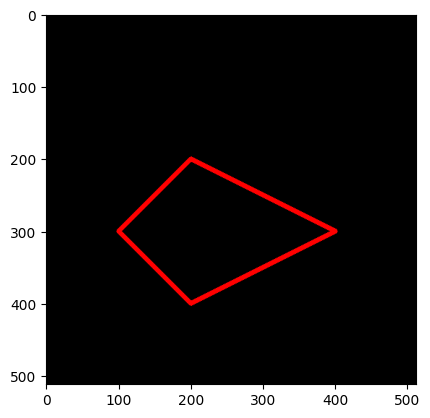

In [42]:
# g. Membuat polyline dengan Numpy array
# black image baru dengan tipe data int32
black_img2 = np.zeros(shape=(512, 512, 3), dtype=np.int32)
plt.imshow(black_img2)

# inisialisasi titik-titik koordinat
vertices = np.array([[100, 300], [200, 200], [400, 300], [200, 400]], dtype=np.int32)
print(vertices)

# reshape array agar sesuai format yang dibutuhkan cv.polylines
pts = vertices.reshape((-1, 1, 2))
print(pts)

# menggambar polyline
cv.polylines(black_img2, [pts], isClosed=True, color=(255, 0, 0), thickness=5)
plt.imshow(black_img2)

In [ ]:
#PERTANYAAN PRAKTIKUM D3
1. Apakah perbedaan gambar yang ditampilkan tanpa dan dengan matplotlib?
2. Apakah perbedaan dan pengaruhnya pembuatan black image antara tipe data
int16 dan int32?
3. Apakah kegunaan “google.colab.patches import cv2_imshow” pada potongan
kode berikut
from google.colab.patches import cv2_imshow
from skimage import io
4. Apakah kegunaan “skimage import io” pada potongan kode soal nomor 3

#JAWABAN
1. Apabila gambar ditampilkan dengan tanpa matplotlib gambar akan menampilkan
apa adanya sesuai gambar asli hasil cv2.imread(), yaitu BGR. Sedangkan apabila
menggunakan pmatplotlib gambar akan menampilkan dengan asumsi urutan channel RGB
sehingga jika sumbernya BGR warna akan terlihat terbalik (biru dan merah tertukar)

2. untuk int6 ukuran meemrinya yaitu 2byte sedangakan untuk int32 2 kali lebih besar yaitu 4 byte
untuk pengaruhnya untuk kebutuhan menggambar bentuk geometri sederhana dengan warna
0–255, int16 sudah cukup dan lebih efisien memori dibanding int32. Penggunaan
int32 baru terasa manfaatnya jika dibutuhkan operasi perhitungan koordinat/nilai
yang lebih besar atau kompleks

3. cv2_imshow adalah fungsi pengganti cv2.imshow() khusus untuk digunakan di
lingkungan Google Colab. Jika cv2.imshow() biasa dipaksakan dijalankan di Colab,
akan muncul error karena tidak ada display yang bisa diakses. Oleh karena itu,
Google menyediakan fungsi cv2_imshow() yang menampilkan

4. Membaca (read) citra dari file lokal maupun langsung dari URL —
misalnya io.imread(url) seperti yang digunakan pada praktikum D2 untuk membaca gambar dari internet.

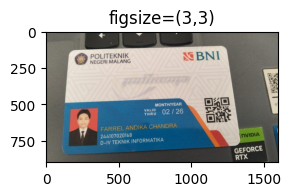

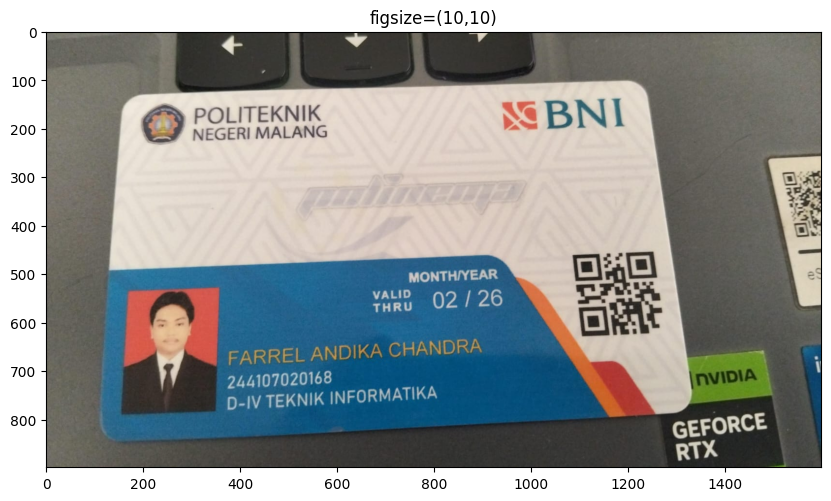

Shape citra tetap: (899, 1599, 3)


In [43]:
# TUGAS PRAKTIKUM D3
# TUGAS 1 Pengaruh figsize terhadap ukuran pixel image
# Menampilkan dengan figsize kecil
fig1 = plt.figure(figsize=(3,3))
ax1 = fig1.add_subplot(111)
ax1.imshow(imgRGB)
plt.title("figsize=(3,3)")
plt.show()

# Menampilkan dengan figsize besar
fig2 = plt.figure(figsize=(10,10))
ax2 = fig2.add_subplot(111)
ax2.imshow(imgRGB)
plt.title("figsize=(10,10)")
plt.show()

# cek ukuran array pixel (shape) - untuk membuktikan apakah berubah
print("Shape citra tetap:", imgRGB.shape)


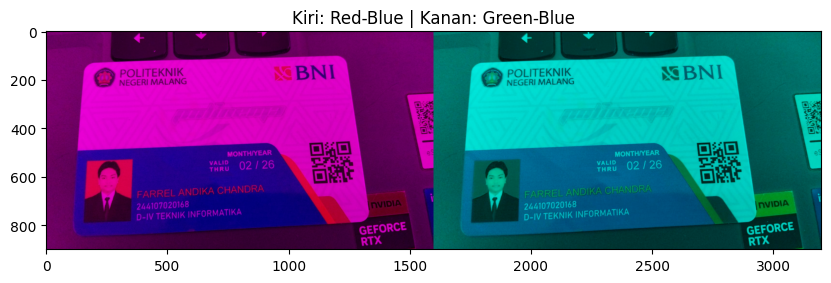

In [44]:
# Tugas 2 — Menampilkan Image dalam Channel Red-Blue dan Green-Blue saja
# Channel Red-Blue saja (Green dihilangkan/dinolkan)
img_RB = imgRGB.copy()
img_RB[:, :, 1] = 0   # index 1 = Green pada format RGB

# Channel Green-Blue saja (Red dihilangkan/dinolkan)
img_GB = imgRGB.copy()
img_GB[:, :, 0] = 0   # index 0 = Red pada format RGB

# tampilkan berdampingan
final_frame = cv2.hconcat((img_RB, img_GB))
plt.figure(figsize=(10,5))
plt.imshow(final_frame)
plt.title("Kiri: Red-Blue | Kanan: Green-Blue")
plt.show()

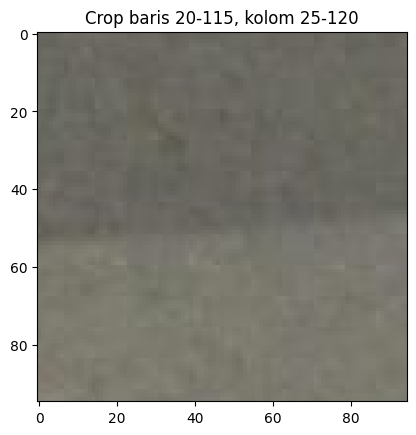

Ukuran hasil crop: (95, 95, 3)


In [45]:
# Tugas 3 Menampilkan Image Baris ke 20-115, Kolom 25-120
img_crop = imgRGB[20:115, 25:120]

plt.imshow(img_crop)
plt.title("Crop baris 20-115, kolom 25-120")
plt.show()

print("Ukuran hasil crop:", img_crop.shape)

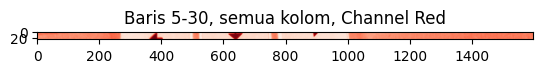

Ukuran hasil: (25, 1599)


In [46]:
# Tugas 4 — Menampilkan Image Baris ke 5-30, Semua Kolom, Channel Red saja
img_red_strip = imgRGB[5:30, :, 0]  # hanya channel Red (index 0)

plt.imshow(img_red_strip, cmap="Reds")
plt.title("Baris 5-30, semua kolom, Channel Red")
plt.show()

print("Ukuran hasil:", img_red_strip.shape)

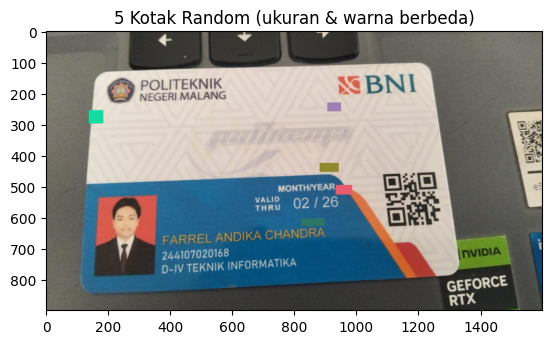

In [47]:
# Tugas 5 — Membuat 5 Kotak Berbagai Ukuran dan Warna Berbeda (Random)
import random

img_kotak = imgRGB.copy()
tinggi, lebar, _ = img_kotak.shape

for i in range(5):
    # koordinat titik awal random
    x1 = random.randint(0, lebar - 50)
    y1 = random.randint(0, tinggi - 50)

    # ukuran kotak random
    w = random.randint(20, 80)
    h = random.randint(20, 80)

    x2 = min(x1 + w, lebar - 1)
    y2 = min(y1 + h, tinggi - 1)

    # warna random (R, G, B)
    warna = (random.randint(0,255), random.randint(0,255), random.randint(0,255))

    cv2.rectangle(img_kotak, pt1=(x1, y1), pt2=(x2, y2), color=warna, thickness=-1)

plt.imshow(img_kotak)
plt.title("5 Kotak Random (ukuran & warna berbeda)")
plt.show()

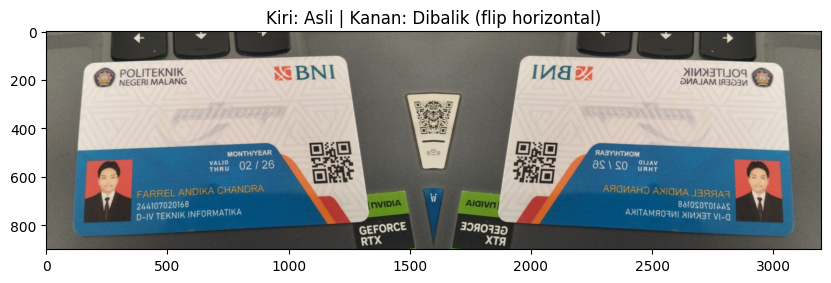

In [48]:
# Tugas 6 — Menampilkan Image dengan Posisi Terbalik
img_flip = cv2.flip(imgRGB, 1)  # 1 = flip horizontal (kiri-kanan)
# alternatif: 0 = flip vertikal (atas-bawah), -1 = flip horizontal & vertikal

final_frame_flip = cv2.hconcat((imgRGB, img_flip))
plt.figure(figsize=(10,5))
plt.imshow(final_frame_flip)
plt.title("Kiri: Asli | Kanan: Dibalik (flip horizontal)")
plt.show()

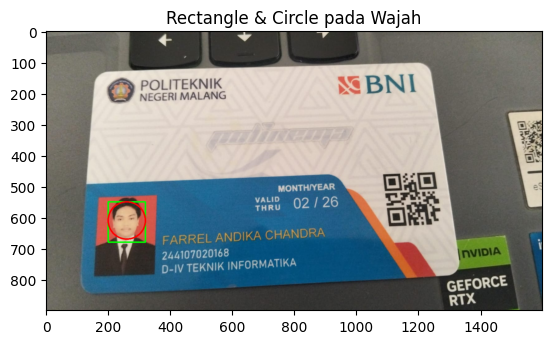

In [74]:
# Tugas 7 — Rectangle dan Circle pada Bagian Wajah (Foto Beraktivitas)
img_wajah = cv2.imread("/content/drive/MyDrive/PCVK/WhatsApp Image 2026-09-01 at 4.54.04 PM.jpeg")
img_wajah = cv2.cvtColor(img_wajah, cv2.COLOR_BGR2RGB)

# --- Sesuaikan koordinat berikut dengan posisi wajah pada foto Anda ---
# Rectangle mengelilingi area wajah
cv2.rectangle(img_wajah, pt1=(200, 550), pt2=(320, 680),
              color=(0, 255, 0), thickness=3)

# Circle menandai area wajah (alternatif/tambahan penanda)
cv2.circle(img_wajah, center=(260, 610), radius=60,
           color=(255, 0, 0), thickness=3)

plt.imshow(img_wajah)
plt.title("Rectangle & Circle pada Wajah")
plt.show()

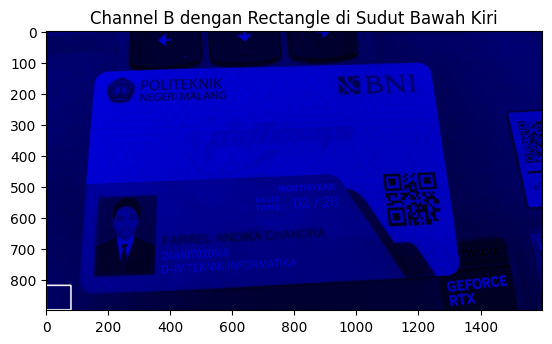

In [78]:
# Tugas 8 - Rectangle di Sudut Bawah Kiri Channel B pada Color Space RGB
img_kitten = cv2.imread("/content/drive/MyDrive/PCVK/WhatsApp Image 2026-09-01 at 4.54.04 PM.jpeg")  # ganti sesuai file citra
img_kitten_RGB = cv2.cvtColor(img_kitten, cv2.COLOR_BGR2RGB)

tinggi, lebar, _ = img_kitten_RGB.shape

# Ambil channel Blue saja (index 2 pada format RGB)
img_channelB = img_kitten_RGB.copy()
img_channelB[:, :, 0] = 0  # nolkan Red
img_channelB[:, :, 1] = 0  # nolkan Green
# channel Blue (index 2) tetap

# Tentukan koordinat rectangle di sudut BAWAH KIRI
ukuran_kotak = 80
pt1 = (0, tinggi - ukuran_kotak)          # pojok kiri bawah area kotak
pt2 = (ukuran_kotak, tinggi - 1)          # geser ke kanan & tetap di bawah

cv2.rectangle(img_channelB, pt1=pt1, pt2=pt2, color=(255, 255, 255), thickness=3)

plt.imshow(img_channelB)
plt.title("Channel B dengan Rectangle di Sudut Bawah Kiri")
plt.show()

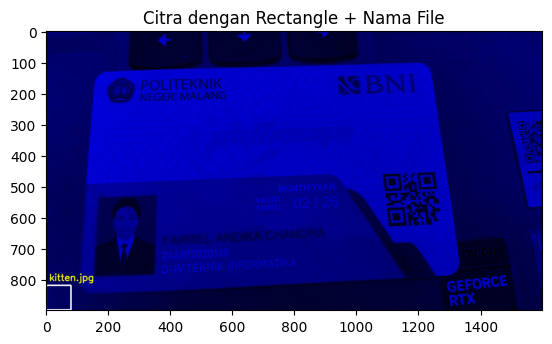

In [79]:
# Tugas 9 — Melengkapi Tulisan Nama File pada Citra Soal No.8
img_final = img_channelB.copy()

font = cv2.FONT_HERSHEY_SIMPLEX
nama_file = "kitten.jpg"   # sesuaikan dengan nama file yang digunakan

cv2.putText(img_final, text=nama_file, org=(10, tinggi - ukuran_kotak - 15),
            fontFace=font, fontScale=1, color=(255, 255, 0),
            thickness=2, lineType=cv2.LINE_AA)

plt.imshow(img_final)
plt.title("Citra dengan Rectangle + Nama File")
plt.show()

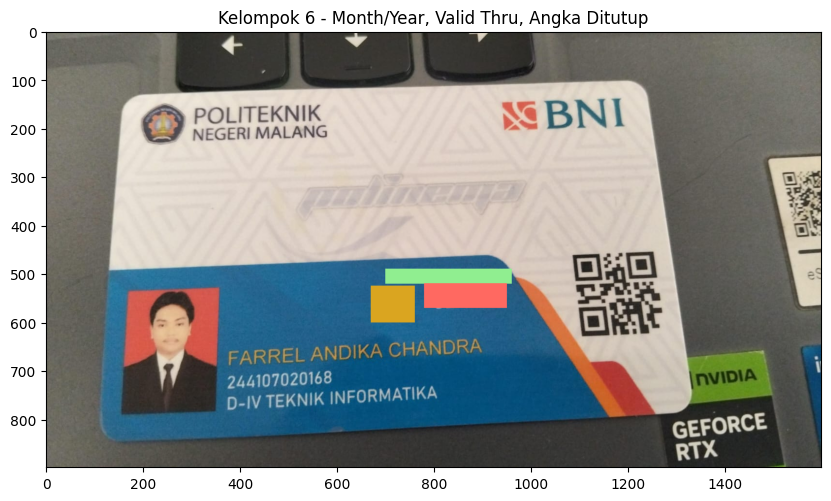

In [184]:
#TUGAS KELOMPOK 6
img_k6 = imgRGB.copy()

# Tutup label "MONTH/YEAR" dengan kotak hijau muda
cv2.rectangle(img_k6, pt1=(700,490), pt2=(960,520), color=(144,238,144), thickness=-1)

# Tutup tulisan "VALID THRU" dengan kotak kuning tua
cv2.rectangle(img_k6, pt1=(670,600), pt2=(760,525), color=(218,165,32), thickness=-1)

# Tutup angka "02/26" dengan kotak merah muda
cv2.rectangle(img_k6, pt1=(780,520), pt2=(950,570), color=(255,105,97), thickness=-1)

plt.figure(figsize=(10,6))
plt.imshow(img_k6)
plt.title("Kelompok 6 - Month/Year, Valid Thru, Angka Ditutup")
plt.show()